# NEXRAD Level 2

In [1]:
import cmweather  # noqa
import xarray as xr
from open_radar_data import DATASETS

import xradar as xd

## Download

Fetching NEXRAD Level2 radar data file from [open-radar-data](https://github.com/openradar/open-radar-data) repository.

In [2]:
filename = DATASETS.fetch("KATX20130717_195021_V06")

## xr.open_dataset

Making use of the xarray `nexradlevel2` backend. We also need to provide the group. Note, that we are using CfRadial2 group access pattern.

In [3]:
ds = xr.open_dataset(filename, group="sweep_0", engine="nexradlevel2")
display(ds)

C:\Users\egoud\.venvs\wradlib\Lib\site-packages\xarray\backends\plugins.py:110: RuntimeWarning: Engine 'radolan' loading failed:
module 'wradlib.georef.raster' has no attribute 'read_gdal_values'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


<xarray.Dataset> Size: 42MB
Dimensions:            (azimuth: 720, range: 1832)
Coordinates:
  * azimuth            (azimuth) float64 6kB 0.2582 0.7526 1.272 ... 359.3 359.8
    elevation          (azimuth) float64 6kB ...
    time               (azimuth) datetime64[ns] 6kB ...
  * range              (range) float32 7kB 2.125e+03 2.375e+03 ... 4.599e+05
    longitude          float64 8B ...
    latitude           float64 8B ...
    altitude           int64 8B ...
Data variables:
    DBZH               (azimuth, range) float64 11MB ...
    ZDR                (azimuth, range) float64 11MB ...
    PHIDP              (azimuth, range) float64 11MB ...
    RHOHV              (azimuth, range) float64 11MB ...
    sweep_mode         <U20 80B ...
    sweep_number       int64 8B ...
    prt_mode           <U7 28B ...
    follow_mode        <U7 28B ...
    sweep_fixed_angle  float64 8B ...
Attributes:
    instrument_name:  KATX
    scan_name:        VCP-11

In [4]:
ds

<xarray.Dataset> Size: 42MB
Dimensions:            (azimuth: 720, range: 1832)
Coordinates:
  * azimuth            (azimuth) float64 6kB 0.2582 0.7526 1.272 ... 359.3 359.8
    elevation          (azimuth) float64 6kB ...
    time               (azimuth) datetime64[ns] 6kB ...
  * range              (range) float32 7kB 2.125e+03 2.375e+03 ... 4.599e+05
    longitude          float64 8B ...
    latitude           float64 8B ...
    altitude           int64 8B ...
Data variables:
    DBZH               (azimuth, range) float64 11MB ...
    ZDR                (azimuth, range) float64 11MB ...
    PHIDP              (azimuth, range) float64 11MB ...
    RHOHV              (azimuth, range) float64 11MB ...
    sweep_mode         <U20 80B ...
    sweep_number       int64 8B ...
    prt_mode           <U7 28B ...
    follow_mode        <U7 28B ...
    sweep_fixed_angle  float64 8B ...
Attributes:
    instrument_name:  KATX
    scan_name:        VCP-11

In [5]:
import numpy as np

np.testing.assert_almost_equal(ds.sweep_fixed_angle.values, 0.4833984)

### Plot Time vs. Azimuth

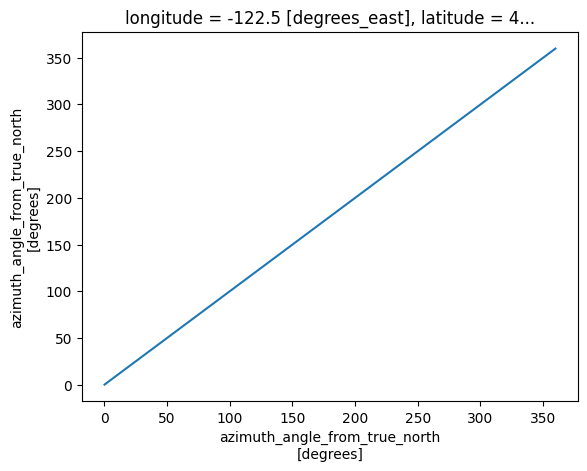

In [6]:
ds.azimuth.plot()

### Plot Range vs. Time

We need to sort by time and specify the y-coordinate.

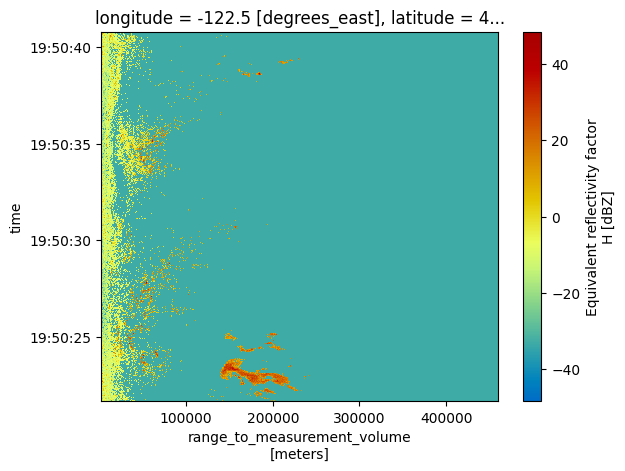

In [7]:
ds.DBZH.sortby("time").plot(y="time", cmap="HomeyerRainbow")

### Plot Range vs. Azimuth


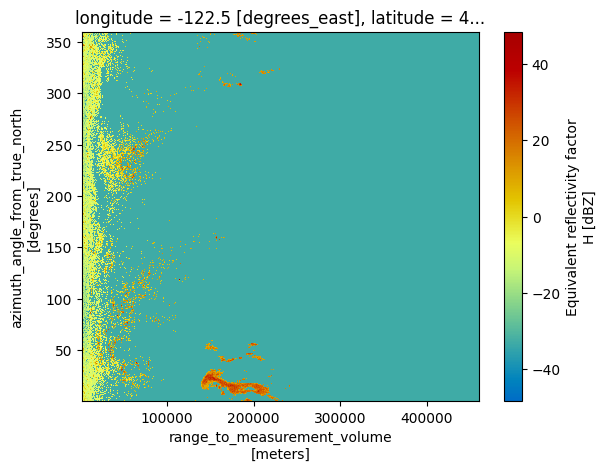

In [8]:
ds.DBZH.plot(cmap="HomeyerRainbow")

## backend_kwargs

Beside `first_dim` there are several additional backend_kwargs for the nexradlevel2 backend, which handle different aspects of angle alignment. This comes into play, when azimuth and/or elevation arrays are not evenly spacend and other issues.

In [9]:
help(xd.io.NexradLevel2BackendEntrypoint)

Help on class NexradLevel2BackendEntrypoint in module xradar.io.backends.nexrad_level2:

class NexradLevel2BackendEntrypoint(xarray.backends.common.BackendEntrypoint)
 |  Xarray BackendEntrypoint for NEXRAD Level2 Data
 |
 |  Method resolution order:
 |      NexradLevel2BackendEntrypoint
 |      xarray.backends.common.BackendEntrypoint
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  open_dataset(
 |      self,
 |      filename_or_obj,
 |      *,
 |      mask_and_scale=True,
 |      decode_times=True,
 |      concat_characters=True,
 |      decode_coords=True,
 |      drop_variables=None,
 |      use_cftime=None,
 |      decode_timedelta=None,
 |      group=None,
 |      lock=None,
 |      first_dim='auto',
 |      reindex_angle=False,
 |      fix_second_angle=False,
 |      site_coords=True,
 |      optional=True
 |  )
 |      Backend open_dataset method used by Xarray in :py:func:`~xarray.open_dataset`.
 |
 |  ---------------------------------------------------------------

In [10]:
ds = xr.open_dataset(filename, group="sweep_0", engine="nexradlevel2", first_dim="time")
display(ds)

<xarray.Dataset> Size: 42MB
Dimensions:            (time: 720, range: 1832)
Coordinates:
    azimuth            (time) float64 6kB ...
    elevation          (time) float64 6kB ...
  * time               (time) datetime64[ns] 6kB 2013-07-17T19:50:21.652000 ....
  * range              (range) float32 7kB 2.125e+03 2.375e+03 ... 4.599e+05
    longitude          float64 8B ...
    latitude           float64 8B ...
    altitude           int64 8B ...
Data variables:
    DBZH               (time, range) float64 11MB ...
    ZDR                (time, range) float64 11MB ...
    PHIDP              (time, range) float64 11MB ...
    RHOHV              (time, range) float64 11MB ...
    sweep_mode         <U20 80B ...
    sweep_number       int64 8B ...
    prt_mode           <U7 28B ...
    follow_mode        <U7 28B ...
    sweep_fixed_angle  float64 8B ...
Attributes:
    instrument_name:  KATX
    scan_name:        VCP-11

## open_nexradlevel2_datatree

The same works analoguous with the datatree loader. But additionally we can provide a sweep string, number or list.

In [11]:
help(xd.io.open_nexradlevel2_datatree)

Help on function open_nexradlevel2_datatree in module xradar.io.backends.nexrad_level2:

open_nexradlevel2_datatree(
    filename_or_obj,
    mask_and_scale=True,
    decode_times=True,
    concat_characters=True,
    decode_coords=True,
    drop_variables=None,
    use_cftime=None,
    decode_timedelta=None,
    sweep=None,
    first_dim='auto',
    reindex_angle=False,
    fix_second_angle=False,
    site_coords=True,
    optional=True,
    lock=None,
    **kwargs
)
    Open a NEXRAD Level2 dataset as :py:class:`xarray.DataTree`.

    This function loads NEXRAD Level2 radar data into a DataTree structure, which
    organizes radar sweeps as separate nodes. Provides options for decoding time
    and applying various transformations to the data.

    Parameters
    ----------
    filename_or_obj : str, Path, file-like, or DataStore
        The path or file-like object representing the radar file.
        Path-like objects are interpreted as local or remote paths.

    mask_and_scale : 

In [12]:
dtree = xd.io.open_nexradlevel2_datatree(filename, sweep=4)
display(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              ()
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2013-07-17T19:51:38Z'
│       time_coverage_end    <U20 80B '2013-07-17T19:52:00Z'
│       longitude            float64 8B -122.5
│       altitude             int64 8B 195
│       latitude             float64 8B 48.19
│   Attributes:
│       Conventions:      None
│       instrument_name:  KATX
│       version:          None
│       title:            None
│       institution:      None
│       references:       None
│       source:           None
│       history:          None
│       comment:          im/exported using xradar
│       scan_name:        VCP-11
├── Group: /sweep_4
│       Dimensions:            (azimuth: 360, range: 1352)
│       Coordinates:
│         * azimuth            (azimuth) float64 3kB 0.563 1.533 2.469 ... 358.5 359.6
│           elevation          (azimuth) float64 3kB 2.461 2.461 2.461 ... 2.461 2.461
│           time               (azimuth) datetime64[ns] 3kB ...
│           range              (range) float32 5kB 2.125e+03 2.375e+03 ... 3.399e+05
│           longitude          float64 8B -122.5
│           latitude           float64 8B 48.19
│           altitude           int64 8B 195
│       Data variables:
│           DBZH               (azimuth, range) float64 4MB ...
│           VRADH              (azimuth, range) float64 4MB ...
│           WRADH              (azimuth, range) float64 4MB ...
│           ZDR                (azimuth, range) float64 4MB ...
│           PHIDP              (azimuth, range) float64 4MB ...
│           RHOHV              (azimuth, range) float64 4MB ...
│           sweep_mode         <U20 80B 'azimuth_surveillance'
│           sweep_number       int64 8B 4
│           prt_mode           <U7 28B 'not_set'
│           follow_mode        <U7 28B 'not_set'
│           sweep_fixed_angle  float64 8B 2.417
├── Group: /radar_parameters
│       Dimensions:    ()
│       Coordinates:
│           longitude  float64 8B -122.5
│           latitude   float64 8B 48.19
│           altitude   int64 8B 195
├── Group: /georeferencing_correction
│       Dimensions:    ()
│       Coordinates:
│           longitude  float64 8B -122.5
│           latitude   float64 8B 48.19
│           altitude   int64 8B 195
└── Group: /radar_calibration

### Plot Sweep Range vs. Time

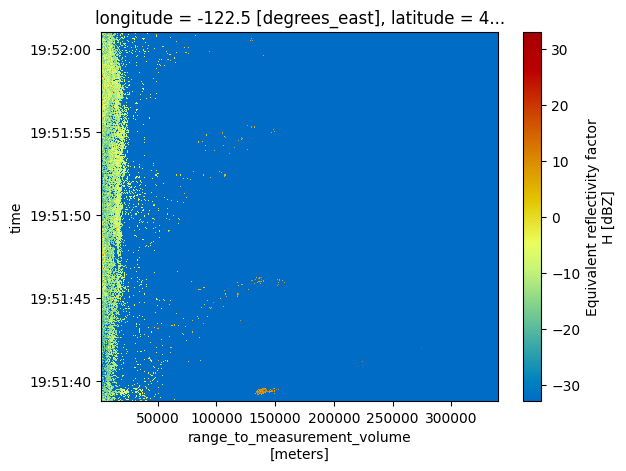

In [13]:
dtree["sweep_4"].ds.DBZH.sortby("time").plot(y="time", cmap="HomeyerRainbow")

### Plot Sweep Range vs. Azimuth

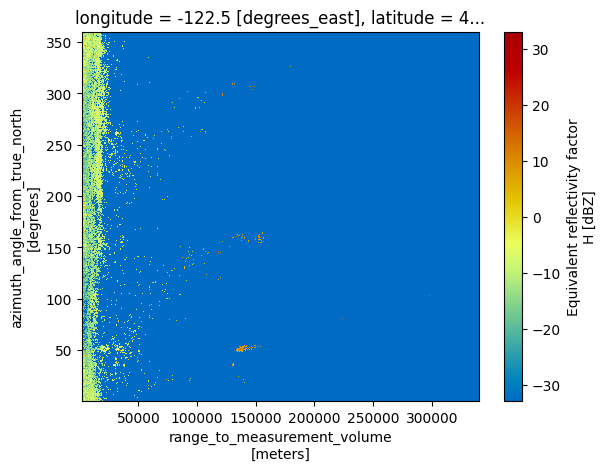

In [14]:
dtree["sweep_4"].ds.DBZH.plot(cmap="HomeyerRainbow")

In [15]:
dtree = xd.io.open_nexradlevel2_datatree(filename, sweep="sweep_8")
display(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              ()
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2013-07-17T19:53:05Z'
│       time_coverage_end    <U20 80B '2013-07-17T19:53:25Z'
│       longitude            float64 8B -122.5
│       altitude             int64 8B 195
│       latitude             float64 8B 48.19
│   Attributes:
│       Conventions:      None
│       instrument_name:  KATX
│       version:          None
│       title:            None
│       institution:      None
│       references:       None
│       source:           None
│       history:          None
│       comment:          im/exported using xradar
│       scan_name:        VCP-11
├── Group: /sweep_8
│       Dimensions:            (azimuth: 360, range: 704)
│       Coordinates:
│         * azimuth            (azimuth) float64 3kB 0.4999 1.513 2.521 ... 358.5 359.5
│           elevation          (azimuth) float64 3kB 6.24 6.24 6.24 ... 6.24 6.24 6.24
│           time               (azimuth) datetime64[ns] 3kB ...
│           range              (range) float32 3kB 2.125e+03 2.375e+03 ... 1.779e+05
│           longitude          float64 8B -122.5
│           latitude           float64 8B 48.19
│           altitude           int64 8B 195
│       Data variables:
│           DBZH               (azimuth, range) float64 2MB ...
│           VRADH              (azimuth, range) float64 2MB ...
│           WRADH              (azimuth, range) float64 2MB ...
│           ZDR                (azimuth, range) float64 2MB ...
│           PHIDP              (azimuth, range) float64 2MB ...
│           RHOHV              (azimuth, range) float64 2MB ...
│           sweep_mode         <U20 80B 'azimuth_surveillance'
│           sweep_number       int64 8B 8
│           prt_mode           <U7 28B 'not_set'
│           follow_mode        <U7 28B 'not_set'
│           sweep_fixed_angle  float64 8B 6.196
├── Group: /radar_parameters
│       Dimensions:    ()
│       Coordinates:
│           longitude  float64 8B -122.5
│           latitude   float64 8B 48.19
│           altitude   int64 8B 195
├── Group: /georeferencing_correction
│       Dimensions:    ()
│       Coordinates:
│           longitude  float64 8B -122.5
│           latitude   float64 8B 48.19
│           altitude   int64 8B 195
└── Group: /radar_calibration

In [16]:
dtree = xd.io.open_nexradlevel2_datatree(filename, sweep=[0, 1, 8])
display(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              ()
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2013-07-17T19:50:21Z'
│       time_coverage_end    <U20 80B '2013-07-17T19:53:25Z'
│       longitude            float64 8B -122.5
│       altitude             int64 8B 195
│       latitude             float64 8B 48.19
│   Attributes:
│       Conventions:      None
│       instrument_name:  KATX
│       version:          None
│       title:            None
│       institution:      None
│       references:       None
│       source:           None
│       history:          None
│       comment:          im/exported using xradar
│       scan_name:        VCP-11
├── Group: /sweep_0
│       Dimensions:            (azimuth: 720, range: 1832)
│       Coordinates:
│         * azimuth            (azimuth) float64 6kB 0.2582 0.7526 1.272 ... 359.3 359.8
│           elevation          (azimuth) float64 6kB 0.6592 0.6592 ... 0.6592 0.6592
│           time               (azimuth) datetime64[ns] 6kB ...
│           range              (range) float32 7kB 2.125e+03 2.375e+03 ... 4.599e+05
│           longitude          float64 8B -122.5
│           latitude           float64 8B 48.19
│           altitude           int64 8B 195
│       Data variables:
│           DBZH               (azimuth, range) float64 11MB ...
│           ZDR                (azimuth, range) float64 11MB ...
│           PHIDP              (azimuth, range) float64 11MB ...
│           RHOHV              (azimuth, range) float64 11MB ...
│           sweep_mode         <U20 80B 'azimuth_surveillance'
│           sweep_number       int64 8B 0
│           prt_mode           <U7 28B 'not_set'
│           follow_mode        <U7 28B 'not_set'
│           sweep_fixed_angle  float64 8B 0.4834
├── Group: /sweep_1
│       Dimensions:            (azimuth: 720, range: 1192)
│       Coordinates:
│         * azimuth            (azimuth) float64 6kB 0.2499 0.7938 1.252 ... 359.2 359.8
│           elevation          (azimuth) float64 6kB 0.5273 0.5273 ... 0.5273 0.5273
│           time               (azimuth) datetime64[ns] 6kB ...
│           range              (range) float32 5kB 2.125e+03 2.375e+03 ... 2.999e+05
│           longitude          float64 8B -122.5
│           latitude           float64 8B 48.19
│           altitude           int64 8B 195
│       Data variables:
│           DBZH               (azimuth, range) float64 7MB ...
│           VRADH              (azimuth, range) float64 7MB ...
│           WRADH              (azimuth, range) float64 7MB ...
│           sweep_mode         <U20 80B 'azimuth_surveillance'
│           sweep_number       int64 8B 1
│           prt_mode           <U7 28B 'not_set'
│           follow_mode        <U7 28B 'not_set'
│           sweep_fixed_angle  float64 8B 0.4834
├── Group: /sweep_8
│       Dimensions:            (azimuth: 360, range: 704)
│       Coordinates:
│         * azimuth            (azimuth) float64 3kB 0.4999 1.513 2.521 ... 358.5 359.5
│           elevation          (azimuth) float64 3kB 6.24 6.24 6.24 ... 6.24 6.24 6.24
│           time               (azimuth) datetime64[ns] 3kB ...
│           range              (range) float32 3kB 2.125e+03 2.375e+03 ... 1.779e+05
│           longitude          float64 8B -122.5
│           latitude           float64 8B 48.19
│           altitude           int64 8B 195
│       Data variables:
│           DBZH               (azimuth, range) float64 2MB ...
│           VRADH              (azimuth, range) float64 2MB ...
│           WRADH              (azimuth, range) float64 2MB ...
│           ZDR                (azimuth, range) float64 2MB ...
│           PHIDP              (azimuth, range) float64 2MB ...
│           RHOHV              (azimuth, range) float64 2MB ...
│           sweep_mode         <U20 80B 'azimuth_surveillance'
│           sweep_n

In [17]:
dtree["sweep_0"]["sweep_fixed_angle"].values

array(0.48339844)

In [18]:
dtree["sweep_8"]["sweep_fixed_angle"].values

array(6.19628906)

In [19]:
dtree = xd.io.open_nexradlevel2_datatree(
    filename,
)
display(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              ()
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2013-07-17T19:50:21Z'
│       time_coverage_end    <U20 80B '2013-07-17T19:55:11Z'
│       longitude            float64 8B -122.5
│       altitude             int64 8B 195
│       latitude             float64 8B 48.19
│   Attributes:
│       Conventions:      None
│       instrument_name:  KATX
│       version:          None
│       title:            None
│       institution:      None
│       references:       None
│       source:           None
│       history:          None
│       comment:          im/exported using xradar
│       scan_name:        VCP-11
├── Group: /sweep_0
│       Dimensions:            (azimuth: 720, range: 1832)
│       Coordinates:
│         * azimuth            (azimuth) float64 6kB 0.2582 0.7526 1.272 ... 359.3 359.8
│           elevation          (azimuth) float64 6kB 0.6592 0.6592 ... 0.6592 0.6592
│           time               (azimuth) datetime64[ns] 6kB ...
│           range              (range) float32 7kB 2.125e+03 2.375e+03 ... 4.599e+05
│           longitude          float64 8B -122.5
│           latitude           float64 8B 48.19
│           altitude           int64 8B 195
│       Data variables:
│           DBZH               (azimuth, range) float64 11MB ...
│           ZDR                (azimuth, range) float64 11MB ...
│           PHIDP              (azimuth, range) float64 11MB ...
│           RHOHV              (azimuth, range) float64 11MB ...
│           sweep_mode         <U20 80B 'azimuth_surveillance'
│           sweep_number       int64 8B 0
│           prt_mode           <U7 28B 'not_set'
│           follow_mode        <U7 28B 'not_set'
│           sweep_fixed_angle  float64 8B 0.4834
├── Group: /sweep_1
│       Dimensions:            (azimuth: 720, range: 1192)
│       Coordinates:
│         * azimuth            (azimuth) float64 6kB 0.2499 0.7938 1.252 ... 359.2 359.8
│           elevation          (azimuth) float64 6kB 0.5273 0.5273 ... 0.5273 0.5273
│           time               (azimuth) datetime64[ns] 6kB ...
│           range              (range) float32 5kB 2.125e+03 2.375e+03 ... 2.999e+05
│           longitude          float64 8B -122.5
│           latitude           float64 8B 48.19
│           altitude           int64 8B 195
│       Data variables:
│           DBZH               (azimuth, range) float64 7MB ...
│           VRADH              (azimuth, range) float64 7MB ...
│           WRADH              (azimuth, range) float64 7MB ...
│           sweep_mode         <U20 80B 'azimuth_surveillance'
│           sweep_number       int64 8B 1
│           prt_mode           <U7 28B 'not_set'
│           follow_mode        <U7 28B 'not_set'
│           sweep_fixed_angle  float64 8B 0.4834
├── Group: /sweep_2
│       Dimensions:            (azimuth: 720, range: 1676)
│       Coordinates:
│         * azimuth            (azimuth) float64 6kB 0.2554 0.7553 1.241 ... 359.3 359.8
│           elevation          (azimuth) float64 6kB 1.494 1.494 1.494 ... 1.494 1.494
│           time               (azimuth) datetime64[ns] 6kB ...
│           range              (range) float32 7kB 2.125e+03 2.375e+03 ... 4.209e+05
│           longitude          float64 8B -122.5
│           latitude           float64 8B 48.19
│           altitude           int64 8B 195
│       Data variables:
│           DBZH               (azimuth, range) float64 10MB ...
│           ZDR                (azimuth, range) float64 10MB ...
│           PHIDP              (azimuth, range) float64 10MB ...
│           RHOHV              (azimuth, range) float64 10MB ...
│           sweep_mode         <U20 80B 'azimuth_surveillance'
│           sweep_number       int64 8B 2
│           prt_mode           <U7 28B 'not_set'
│           follow_mode        <U7 28B 'not_set'
│

In [20]:
dtree["sweep_1"]

<xarray.DataTree 'sweep_1'>
Group: /sweep_1
    Dimensions:            (azimuth: 720, range: 1192)
    Coordinates:
      * azimuth            (azimuth) float64 6kB 0.2499 0.7938 1.252 ... 359.2 359.8
        elevation          (azimuth) float64 6kB 0.5273 0.5273 ... 0.5273 0.5273
        time               (azimuth) datetime64[ns] 6kB ...
        range              (range) float32 5kB 2.125e+03 2.375e+03 ... 2.999e+05
        longitude          float64 8B -122.5
        latitude           float64 8B 48.19
        altitude           int64 8B 195
    Data variables:
        DBZH               (azimuth, range) float64 7MB ...
        VRADH              (azimuth, range) float64 7MB ...
        WRADH              (azimuth, range) float64 7MB ...
        sweep_mode         <U20 80B 'azimuth_surveillance'
        sweep_number       int64 8B 1
        prt_mode           <U7 28B 'not_set'
        follow_mode        <U7 28B 'not_set'
        sweep_fixed_angle  float64 8B 0.4834